In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
import matplotlib.pyplot as plt
print("all done...")


all done...


In [4]:
# Dataset download
import urllib.request
url = "https://huggingface.co/datasets/HUBioDataLab/SELFormerMM/resolve/main/finetuning_datasets/classification/bbbp/bbbp.csv"
try:
    df = pd.read_csv(url)
    print("Download successful!")
except:
    print("Download failed! using backup URL...")
    url2 = "https://raw.githubusercontent.com/GLambard/Molecules_Dataset_Collection/master/latest/BBBP.csv"
    try:
        df = pd.read_csv(url2)
        print("Backup url valid!")
    except:
        print("Both Urls failed...")
print(df.shape)
print(df.head())

Download successful!
(2039, 9)
                                             selfies  \
0  [ClH0].[C][C][Branch1][C][C][N][C][C][Branch1]...   
1  [C][=Branch1][C][=O][Branch1][#Branch2][O][C][...   
2  [C][=C][C][Branch1][N][N][C][C][N][Branch1][C]...   
3  [C][C][C][N][Branch1][Branch1][C][C][Ring1][=B...   
4  [C][C][O][N][=C][Branch1][#Branch2][C][=C][C][...   

                                              smiles  p_np  \
0                   [Cl].CC(C)NCC(O)COc1cccc2ccccc12     1   
1           C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl     1   
2  c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...     1   
3                   C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C     1   
4  Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...     1   

            standard_inchi_key     cid  \
0  AOLIYNUVSUQXCB-UHFFFAOYSA-N     NaN   
1  SZXDOYFHSIIZCF-UHFFFAOYSA-N     NaN   
2  GSDSWSVVBLHKDQ-UHFFFAOYSA-N  4583.0   
3  FAXLXLJWHQJMPK-UHFFFAOYSA-N     NaN   
4  LQOLIRLGBULYKD-JKIFEVAISA-N  6098.0   

      

In [5]:
# data cleaning
df = df[['smiles', 'p_np']].dropna()
df = df[df['smiles'].str.strip() != '']
df = df.reset_index(drop=True)
print(f"Clean dataset size: {len(df)}")
print(f"Label distribution: \n{df['p_np'].value_counts()}")

Clean dataset size: 2039
Label distribution: 
p_np
1    1560
0     479
Name: count, dtype: int64


In [11]:
from rdkit.Chem import rdFingerprintGenerator

def smiles_to_fingerprint(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    fp = gen.GetFingerprintAsNumPy(mol)
    return fp

fingerprints = df["smiles"].apply(smiles_to_fingerprint)

mask = fingerprints.notna()
X = np.stack(fingerprints[mask].values)
y = df['p_np'][mask].values

print(f"Features matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")

[16:33:28] WARNING: not removing hydrogen atom without neighbors
[16:33:28] WARNING: not removing hydrogen atom without neighbors
[16:33:28] WARNING: not removing hydrogen atom without neighbors
[16:33:28] WARNING: not removing hydrogen atom without neighbors
[16:33:28] WARNING: not removing hydrogen atom without neighbors
[16:33:28] WARNING: not removing hydrogen atom without neighbors
[16:33:28] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not r

Features matrix shape: (2039, 2048)
Labels shape: (2039,)


[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors
[16:33:29] WARNING: not removing hydrogen atom without neighbors


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)
print("Model Trained!")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")



Model Trained!
Train size: 1631, Test size: 408


In [13]:
# evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.935

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.62      0.75        96
           1       0.90      0.98      0.94       312

    accuracy                           0.90       408
   macro avg       0.91      0.80      0.84       408
weighted avg       0.90      0.90      0.89       408



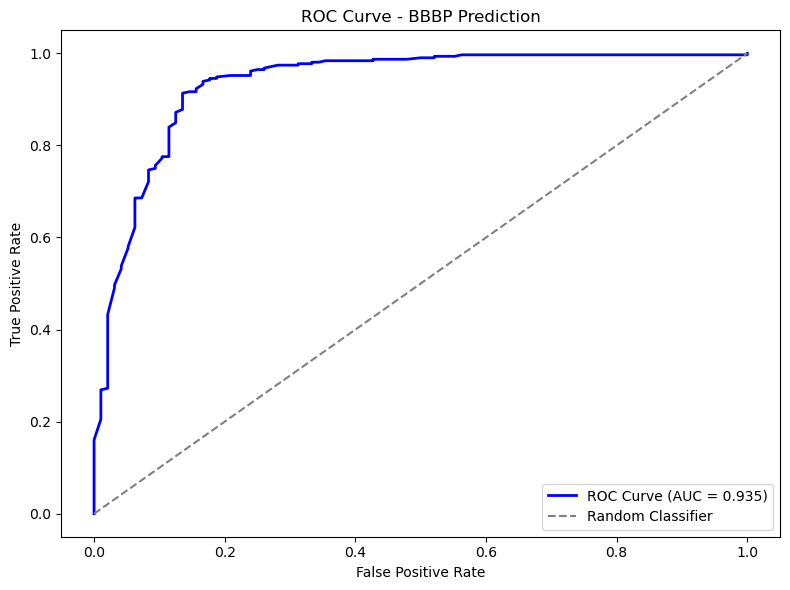

Plot saved!


In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BBBP Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("Plot saved!")

In [17]:
# results

print("=" * 45)
print("      PROJECT BBBP PREDICTION SUMMARY")
print("=" * 45)
print(f"Dataset:        BBBP ({len(df)} compounds)")
print(f"Features:       Morgan Fingerprints (2048 bits)")
print(f"Model:          Random Forest (100 trees)")
print(f"Train/Test:     80/20 split")
print(f"ROC-AUC:        {auc:.3f}")
print(f"Accuracy:       0.90")
print(f"Note:           class_weight=balanced (imbalanced data)")
print("=" * 45)


      PROJECT BBBP PREDICTION SUMMARY
Dataset:        BBBP (2039 compounds)
Features:       Morgan Fingerprints (2048 bits)
Model:          Random Forest (100 trees)
Train/Test:     80/20 split
ROC-AUC:        0.935
Accuracy:       0.90
Note:           class_weight=balanced (imbalanced data)
